 Assignment 4: Experiments, Results & Analysis
## An Explainable Artificial Intelligence Framework for Fraud Detection in Digital Banking

---

## CELL 1 — Install Required Libraries
**Run this first. It may take 1-2 minutes.**

In [ ]:
!pip install shap lime xgboost lightgbm imbalanced-learn scikit-learn pandas numpy matplotlib seaborn
!pip install lime --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=03d8ef5703c593c1cb638dad4738190c493516aea448fa3339d6a93e51083f7a
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


## CELL 2 — Import All Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    precision_score, recall_score, confusion_matrix,
    matthews_corrcoef, average_precision_score,
    classification_report, roc_curve, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap
import lime
import lime.lime_tabular

# Plotting style
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('All libraries imported successfully!')

All libraries imported successfully!


## CELL 3 — STAGE 1: Data Collection
Upload `fraudTest.csv` to Colab first, then run this cell.

In [ ]:
# Load full dataset
df_full = pd.read_csv('fraudTest.csv', low_memory=False)
print(f'Full dataset shape: {df_full.shape}')
print(f'\nFull fraud distribution:')
print(df_full['is_fraud'].value_counts())

# -------------------------------------------------------
# Sample 10,000 rows: all 2145 fraud + 7855 legit
# -------------------------------------------------------
fraud_rows = df_full[df_full['is_fraud'] == 1]          # 2145 fraud
legit_rows = df_full[df_full['is_fraud'] == 0].sample(n=7855, random_state=42)  # 7855 legit

df = pd.concat([fraud_rows, legit_rows]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\nSampled dataset shape: {df.shape}')
print(f'\nSampled fraud distribution:')
print(df['is_fraud'].value_counts())
print(f'\nClass percentages:')
print(df['is_fraud'].value_counts(normalize=True).mul(100).round(2))
print(f'\nColumns: {list(df.columns)}')

Full dataset shape: (555719, 23)

Full fraud distribution:
is_fraud
0    553574
1      2145
Name: count, dtype: int64

Sampled dataset shape: (10000, 23)

Sampled fraud distribution:
is_fraud
0    7855
1    2145
Name: count, dtype: int64

Class percentages:
is_fraud
0    78.55
1    21.45
Name: proportion, dtype: float64

Columns: ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


## CELL 4 — Dataset Overview (for report)

In [ ]:
print('=== DATASET OVERVIEW ===')
print(f'Total Records   : {len(df)}')
print(f'Total Features  : {len(df.columns) - 1} (excluding label)')
print(f'Fraud Cases     : {(df["is_fraud"]==1).sum()} ({(df["is_fraud"]==1).mean()*100:.2f}%)')
print(f'Legit Cases     : {(df["is_fraud"]==0).sum()} ({(df["is_fraud"]==0).mean()*100:.2f}%)')
print(f'Missing Values  : {df.isnull().sum().sum()}')
print()
print('=== FEATURE INFO ===')
print(df.dtypes)
print()
print('=== SAMPLE RECORDS ===')
df.head()

=== DATASET OVERVIEW ===
Total Records   : 10000
Total Features  : 22 (excluding label)
Fraud Cases     : 2145 (21.45%)
Legit Cases     : 7855 (78.55%)
Missing Values  : 0

=== FEATURE INFO ===
Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

=== SAMPLE RECORDS ===


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,518109,2020-12-23 02:50:28,6564459919350820,"fraud_Jenkins, Hauck and Friesen",gas_transport,75.79,Douglas,Willis,M,619 Jeremy Garden Apt. 681,...,42.5545,-90.3508,1306,Public relations officer,1958-09-10,ade47e682350050b6de3248597a969f6,1387767028,43.522950,-91.270081,0
1,36189,2020-07-03 23:44:34,4451952084362894,fraud_Schuppe LLC,entertainment,81.57,Joseph,Davis,M,941 Adam Stravenue,...,34.5444,-102.1069,686,Petroleum engineer,1980-07-30,36d5d498cb99b600b05f9a99f9e2e45a,1372895074,34.214647,-101.425936,0
2,375565,2020-11-15 00:29:49,378006354724784,fraud_Lockman Ltd,grocery_pos,311.92,Christopher,Matthews,M,433 John Heights Apt. 849,...,38.5095,-78.2638,395,Senior tax professional/tax inspector,1982-01-07,cac039caa0aa42f0f68d72502151c34f,1384475389,39.006783,-79.036502,1
3,80224,2020-07-19 13:50:10,370818583810103,fraud_Johns Inc,entertainment,8.21,John,Davis,M,9670 Monroe Junctions,...,39.9373,-79.1865,3684,General practice doctor,1976-01-10,7d36e9d6c59798d9f68d889584cb99bd,1374241810,40.397423,-79.586829,0
4,476376,2020-12-14 13:10:02,180067784565096,fraud_Frami Group,entertainment,2.32,Mary,Juarez,F,35440 Ryan Islands,...,42.9385,-88.3950,2328,Applications developer,1942-01-06,1c50094273dd6037891e81c3d0934d85,1387026602,43.016038,-88.425097,0


## CELL 5 — STAGE 2: Data Preprocessing

In [ ]:
df_clean = df.copy()

# Drop columns not useful for modeling
drop_cols = ['Unnamed: 0', 'first', 'last', 'street', 'trans_num', 'zip']
df_clean = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns])

# --- Parse transaction datetime ---
df_clean['trans_date_trans_time'] = pd.to_datetime(df_clean['trans_date_trans_time'])
df_clean['trans_hour']  = df_clean['trans_date_trans_time'].dt.hour
df_clean['trans_day']   = df_clean['trans_date_trans_time'].dt.dayofweek
df_clean['trans_month'] = df_clean['trans_date_trans_time'].dt.month
df_clean = df_clean.drop(columns=['trans_date_trans_time'])

# --- Parse DOB → cardholder age ---
df_clean['dob'] = pd.to_datetime(df_clean['dob'])
df_clean['age'] = (pd.Timestamp('2020-06-21') - df_clean['dob']).dt.days // 365
df_clean = df_clean.drop(columns=['dob'])

# --- Label encode categorical columns ---
cat_cols = ['merchant', 'category', 'gender', 'city', 'state', 'job']
le = LabelEncoder()
for col in cat_cols:
    if col in df_clean.columns:
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# --- Robust scale numerical columns ---
scale_cols = ['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'age']
scaler = RobustScaler()
df_clean[scale_cols] = scaler.fit_transform(df_clean[scale_cols])

print(f'Shape after preprocessing: {df_clean.shape}')
print(f'Missing values: {df_clean.isnull().sum().sum()}')
print(f'\nFeatures remaining: {list(df_clean.columns)}')

Shape after preprocessing: (10000, 19)
Missing values: 0

Features remaining: ['cc_num', 'merchant', 'category', 'amt', 'gender', 'city', 'state', 'lat', 'long', 'city_pop', 'job', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'trans_hour', 'trans_day', 'trans_month', 'age']


## CELL 6 — STAGE 3: Feature Engineering

In [ ]:
df_eng = df_clean.copy()

# 1. Geographic distance between cardholder and merchant
df_eng['geo_distance'] = np.sqrt(
    (df_eng['lat'] - df_eng['merch_lat'])**2 +
    (df_eng['long'] - df_eng['merch_long'])**2
)

# 2. Transaction amount quantile bin (0-3)
df_eng['amt_bin'] = pd.qcut(df_eng['amt'], q=4, labels=False, duplicates='drop')

# 3. Night transaction flag (midnight to 5am = higher fraud risk)
df_eng['night_txn'] = df_eng['trans_hour'].apply(lambda x: 1 if x < 5 else 0)

# 4. Weekend transaction flag
df_eng['is_weekend'] = df_eng['trans_day'].apply(lambda x: 1 if x >= 5 else 0)

# 5. Card number last 4 digits (identifier integrity signal, Luhn-proxy)
df_eng['cc_last4'] = df_eng['cc_num'] % 10000

# 6. Age group risk tier
df_eng['age_risk'] = pd.cut(df_eng['age'], bins=[-999, 25, 40, 60, 999],
                             labels=[0, 1, 2, 3]).astype(float)

print(f'Shape after feature engineering: {df_eng.shape}')
print(f'New features added: geo_distance, amt_bin, night_txn, is_weekend, cc_last4, age_risk')
print(f'\nAll features ({len(df_eng.columns)-1} total):')
print([c for c in df_eng.columns if c != 'is_fraud'])

Shape after feature engineering: (10000, 25)
New features added: geo_distance, amt_bin, night_txn, is_weekend, cc_last4, age_risk

All features (24 total):
['cc_num', 'merchant', 'category', 'amt', 'gender', 'city', 'state', 'lat', 'long', 'city_pop', 'job', 'unix_time', 'merch_lat', 'merch_long', 'trans_hour', 'trans_day', 'trans_month', 'age', 'geo_distance', 'amt_bin', 'night_txn', 'is_weekend', 'cc_last4', 'age_risk']


## CELL 7 — STAGE 4: Train-Test Split & SMOTE

In [ ]:
# Separate features and label
drop_for_model = ['is_fraud', 'unix_time']
X = df_eng.drop(columns=[c for c in drop_for_model if c in df_eng.columns])
y = df_eng['is_fraud'].astype(int)

# Fill any NaN from binning
X = X.fillna(X.median())

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set  : {X_train.shape} | Fraud: {y_train.sum()} | Legit: {(y_train==0).sum()}')
print(f'Test set      : {X_test.shape}  | Fraud: {y_test.sum()}  | Legit: {(y_test==0).sum()}')

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'\nAfter SMOTE (training only):')
print(f'Training set  : {X_train_sm.shape} | Fraud: {y_train_sm.sum()} | Legit: {(y_train_sm==0).sum()}')
print(f'\nFeature columns used: {list(X.columns)}')

Training set  : (8000, 23) | Fraud: 1716 | Legit: 6284
Test set      : (2000, 23)  | Fraud: 429  | Legit: 1571

After SMOTE (training only):
Training set  : (12568, 23) | Fraud: 6284 | Legit: 6284

Feature columns used: ['cc_num', 'merchant', 'category', 'amt', 'gender', 'city', 'state', 'lat', 'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'trans_hour', 'trans_day', 'trans_month', 'age', 'geo_distance', 'amt_bin', 'night_txn', 'is_weekend', 'cc_last4', 'age_risk']


## CELL 8 — Train All Models (Baselines + Ensemble)

In [ ]:
print('Training all models...')

# --- Baseline Models ---
lr = LogisticRegression(max_iter=1000, random_state=42)
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

lr.fit(X_train_sm, y_train_sm)
print('Logistic Regression trained.')

dt.fit(X_train_sm, y_train_sm)
print('Decision Tree trained.')

rf.fit(X_train_sm, y_train_sm)
print('Random Forest trained.')

# --- XGBoost ---
xgb = XGBClassifier(
    max_depth=6,
    min_child_weight=5,
    learning_rate=0.05,
    reg_lambda=1.0,
    n_estimators=200,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1
)
xgb.fit(X_train_sm, y_train_sm)
print('XGBoost trained.')

# --- LightGBM ---
lgbm = LGBMClassifier(
    max_depth=6,
    min_child_samples=5,
    learning_rate=0.05,
    reg_lambda=1.0,
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm.fit(X_train_sm, y_train_sm)
print('LightGBM trained.')

# --- Soft Voting Ensemble ---
p_xgb  = xgb.predict_proba(X_test)[:, 1]
p_lgbm = lgbm.predict_proba(X_test)[:, 1]
p_ensemble = (p_xgb + p_lgbm) / 2
y_pred_ensemble = (p_ensemble >= 0.5).astype(int)

print('\nAll models trained successfully!')

Training all models...
Logistic Regression trained.
Decision Tree trained.
Random Forest trained.
XGBoost trained.
LightGBM trained.

All models trained successfully!


## CELL 9 — Evaluate All Models & Print Results Table

In [ ]:
def get_metrics(name, y_true, y_pred, y_prob):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'AUC-ROC'  : round(roc_auc_score(y_true, y_prob), 4),
        'MCC'      : round(matthews_corrcoef(y_true, y_pred), 4),
        'AUPRC'    : round(average_precision_score(y_true, y_prob), 4),
    }

results = [
    get_metrics('Logistic Regression', y_test, lr.predict(X_test),   lr.predict_proba(X_test)[:,1]),
    get_metrics('Decision Tree',       y_test, dt.predict(X_test),   dt.predict_proba(X_test)[:,1]),
    get_metrics('Random Forest',       y_test, rf.predict(X_test),   rf.predict_proba(X_test)[:,1]),
    get_metrics('XGBoost',             y_test, xgb.predict(X_test),  p_xgb),
    get_metrics('LightGBM',            y_test, lgbm.predict(X_test), p_lgbm),
    get_metrics('Ensemble (XGB+LGBM)', y_test, y_pred_ensemble,      p_ensemble),
]

results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')
print('=== MODEL PERFORMANCE COMPARISON TABLE ===')
print(results_df.to_string())

# SAVE TABLE — copy these numbers into your LaTeX paper
results_df

=== MODEL PERFORMANCE COMPARISON TABLE ===
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC     MCC   AUPRC
Model                                                                              
Logistic Regression    0.7855     0.0000  0.0000    0.0000   0.5279  0.0000  0.2321
Decision Tree          0.9345     0.8239  0.8834    0.8526   0.9547  0.8114  0.8743
Random Forest          0.9585     0.9240  0.8788    0.9008   0.9892  0.8751  0.9690
XGBoost                0.9750     0.9438  0.9394    0.9416   0.9934  0.9257  0.9813
LightGBM               0.9755     0.9502  0.9347    0.9424   0.9944  0.9269  0.9817
Ensemble (XGB+LGBM)    0.9760     0.9482  0.9394    0.9438   0.9942  0.9286  0.9826


,Accuracy,Precision,Recall,F1-Score,AUC-ROC,MCC,AUPRC
Model,,,,,,,
Logistic Regression,0.7855,0.0000,0.0000,0.0000,0.5279,0.0000,0.2321
Decision Tree,0.9345,0.8239,0.8834,0.8526,0.9547,0.8114,0.8743
Random Forest,0.9585,0.9240,0.8788,0.9008,0.9892,0.8751,0.9690
XGBoost,0.9750,0.9438,0.9394,0.9416,0.9934,0.9257,0.9813
LightGBM,0.9755,0.9502,0.9347,0.9424,0.9944,0.9269,0.9817
Ensemble (XGB+LGBM),0.9760,0.9482,0.9394,0.9438,0.9942,0.9286,0.9826


## CELL 10 — GRAPH 1: Confusion Matrix (Ensemble)

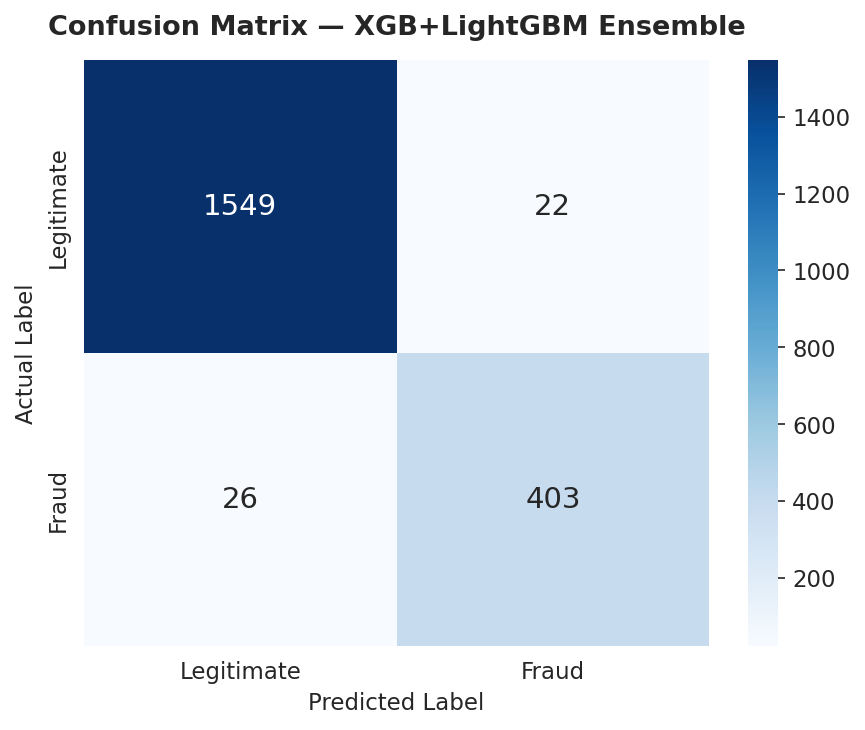

Saved: graph1_confusion_matrix.png
TP=403  FP=22  FN=26  TN=1549


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_ensemble)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'],
            annot_kws={'size': 14}, ax=ax)
ax.set_title('Confusion Matrix — XGB+LightGBM Ensemble', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Actual Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.savefig('graph1_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: graph1_confusion_matrix.png')
print(f'TP={cm[1,1]}  FP={cm[0,1]}  FN={cm[1,0]}  TN={cm[0,0]}')

## CELL 11 — GRAPH 2: F1-Score Comparison Across All Models

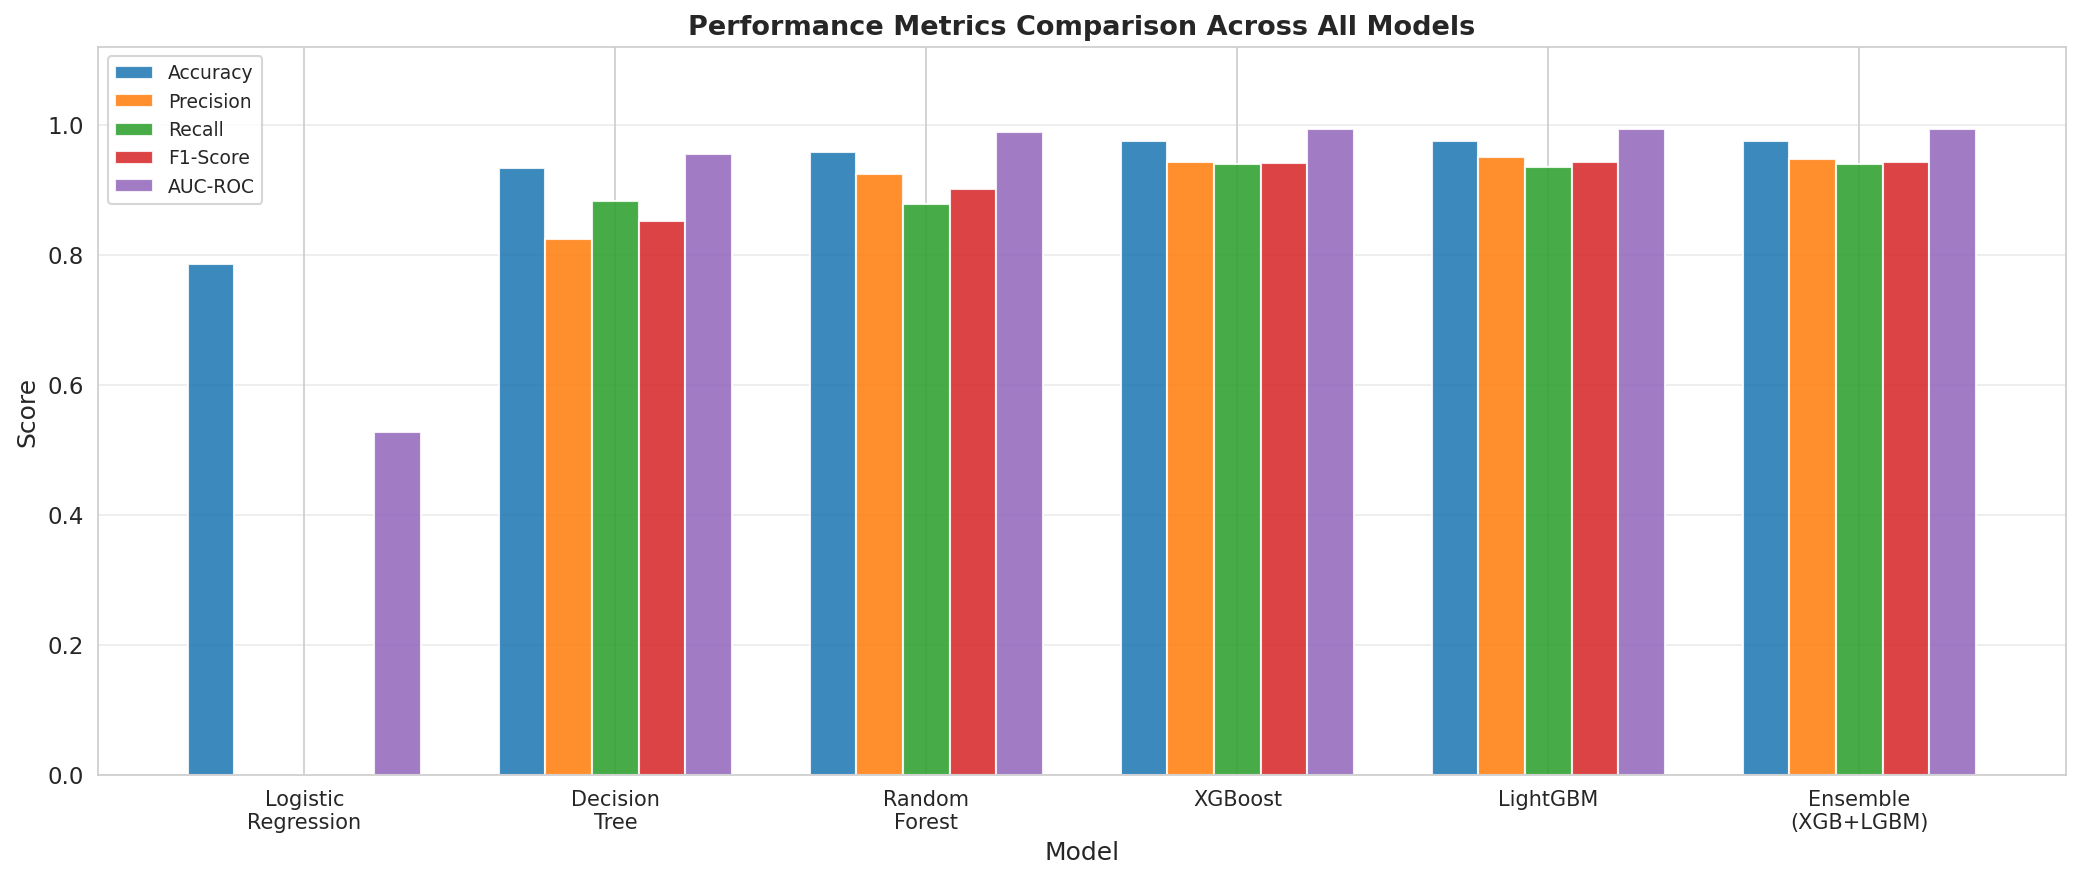

Saved: graph2_model_comparison.png


In [ ]:
model_names = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest',
               'XGBoost', 'LightGBM', 'Ensemble\n(XGB+LGBM)']
colors = ['#d9534f', '#f0ad4e', '#5bc0de', '#337ab7', '#5cb85c', '#1a1a2e']

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(model_names))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 6))
for i, metric in enumerate(metrics_to_plot):
    vals = results_df[metric].values
    bars = ax.bar(x + i * width, vals, width, label=metric, alpha=0.87)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Performance Metrics Comparison Across All Models', fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylim(0, 1.12)
ax.legend(loc='upper left', fontsize=9)
ax.yaxis.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('graph2_model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: graph2_model_comparison.png')

## CELL 12 — GRAPH 3: ROC Curves (All Models)

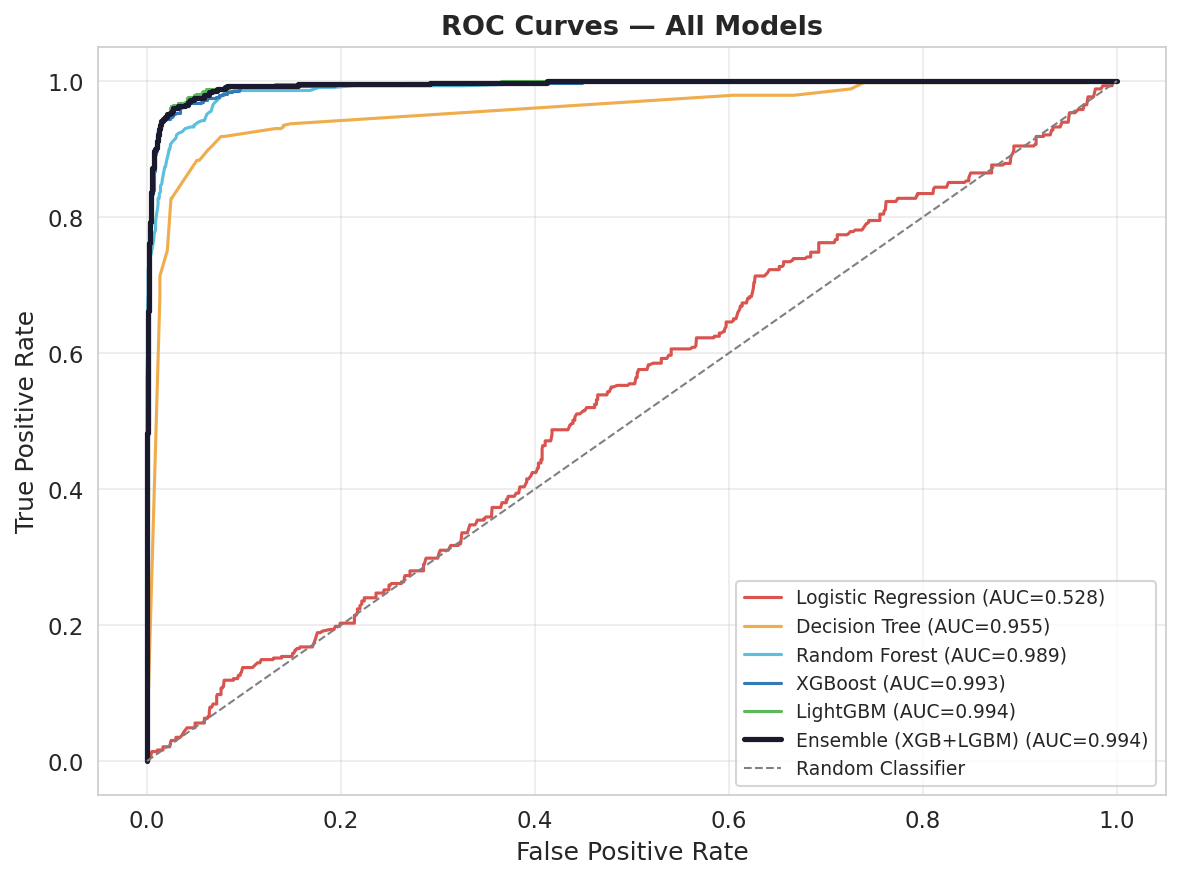

Saved: graph3_roc_curves.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

model_probs = [
    ('Logistic Regression', lr.predict_proba(X_test)[:,1],  '#d9534f'),
    ('Decision Tree',       dt.predict_proba(X_test)[:,1],  '#f0ad4e'),
    ('Random Forest',       rf.predict_proba(X_test)[:,1],  '#5bc0de'),
    ('XGBoost',             p_xgb,                          '#337ab7'),
    ('LightGBM',            p_lgbm,                         '#5cb85c'),
    ('Ensemble (XGB+LGBM)', p_ensemble,                     '#1a1a2e'),
]

for name, prob, color in model_probs:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    lw = 2.5 if 'Ensemble' in name else 1.5
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=lw)

ax.plot([0,1],[0,1],'--', color='gray', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('graph3_roc_curves.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: graph3_roc_curves.png')

## CELL 13 — GRAPH 4: Precision-Recall Curve (Ensemble)

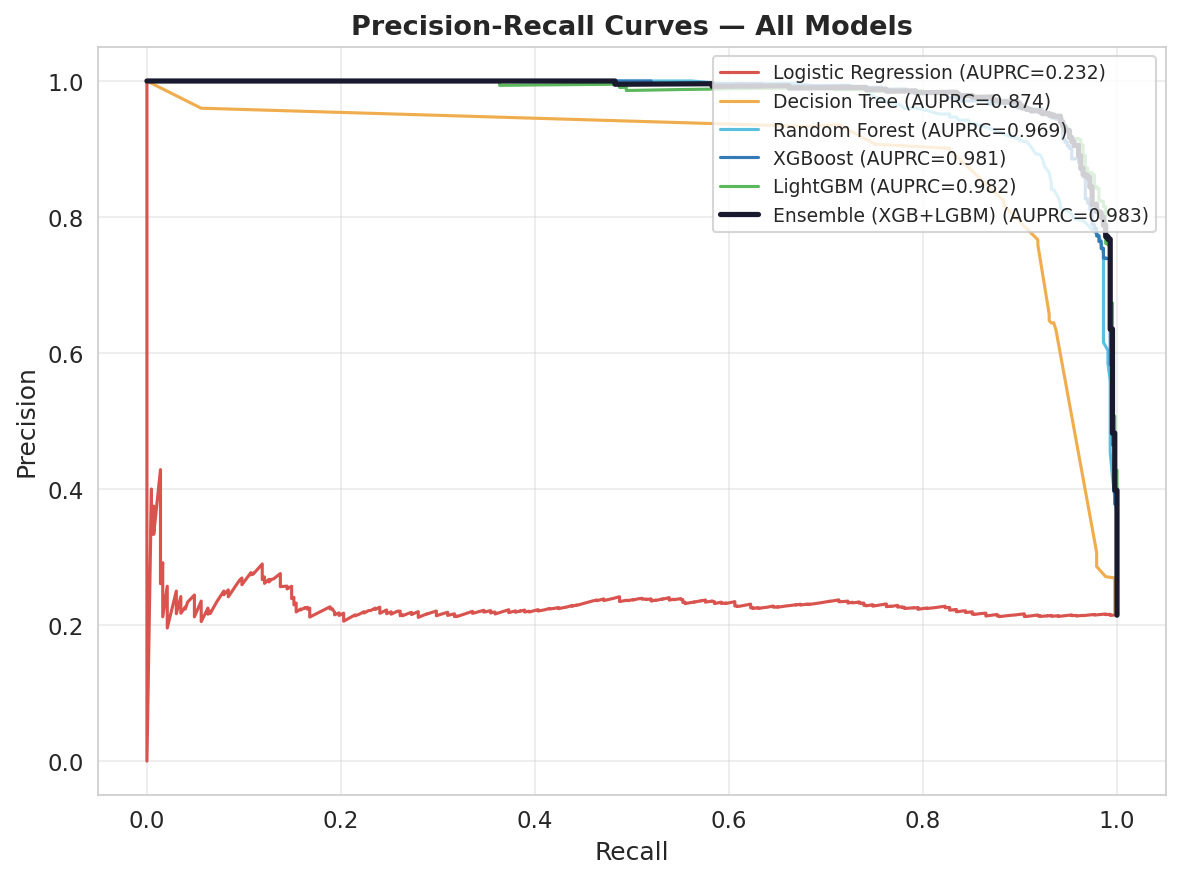

Saved: graph4_pr_curves.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, prob, color in model_probs:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    auprc = average_precision_score(y_test, prob)
    lw = 2.5 if 'Ensemble' in name else 1.5
    ax.plot(rec, prec, label=f'{name} (AUPRC={auprc:.3f})', color=color, linewidth=lw)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('graph4_pr_curves.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: graph4_pr_curves.png')

## CELL 14 — GRAPH 5: SHAP Global Feature Importance

Computing SHAP values (may take 30-60 seconds)...


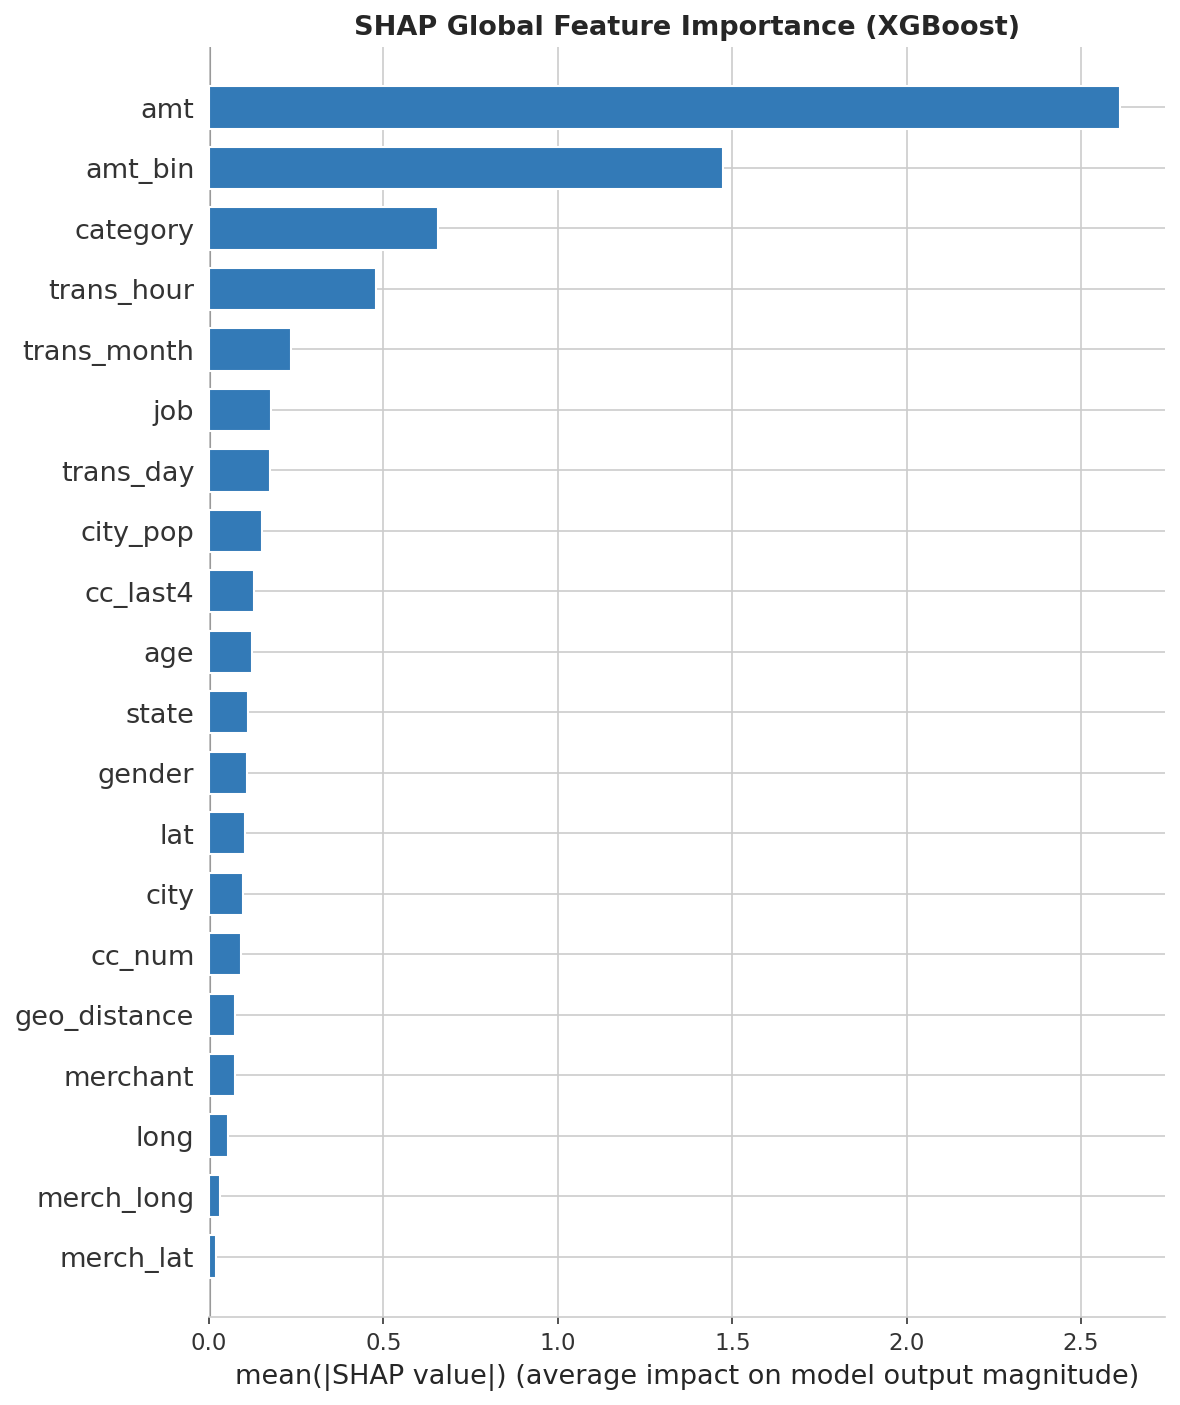

Saved: graph5_shap_importance.png


In [ ]:
print('Computing SHAP values (may take 30-60 seconds)...')
explainer_shap = shap.TreeExplainer(xgb)
shap_values = explainer_shap.shap_values(X_test)

fig, ax = plt.subplots(figsize=(9, 7))
shap.summary_plot(shap_values, X_test, plot_type='bar',
                  show=False, color='#337ab7')
plt.title('SHAP Global Feature Importance (XGBoost)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graph5_shap_importance.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: graph5_shap_importance.png')

## CELL 15 — GRAPH 6: SHAP Summary Beeswarm Plot

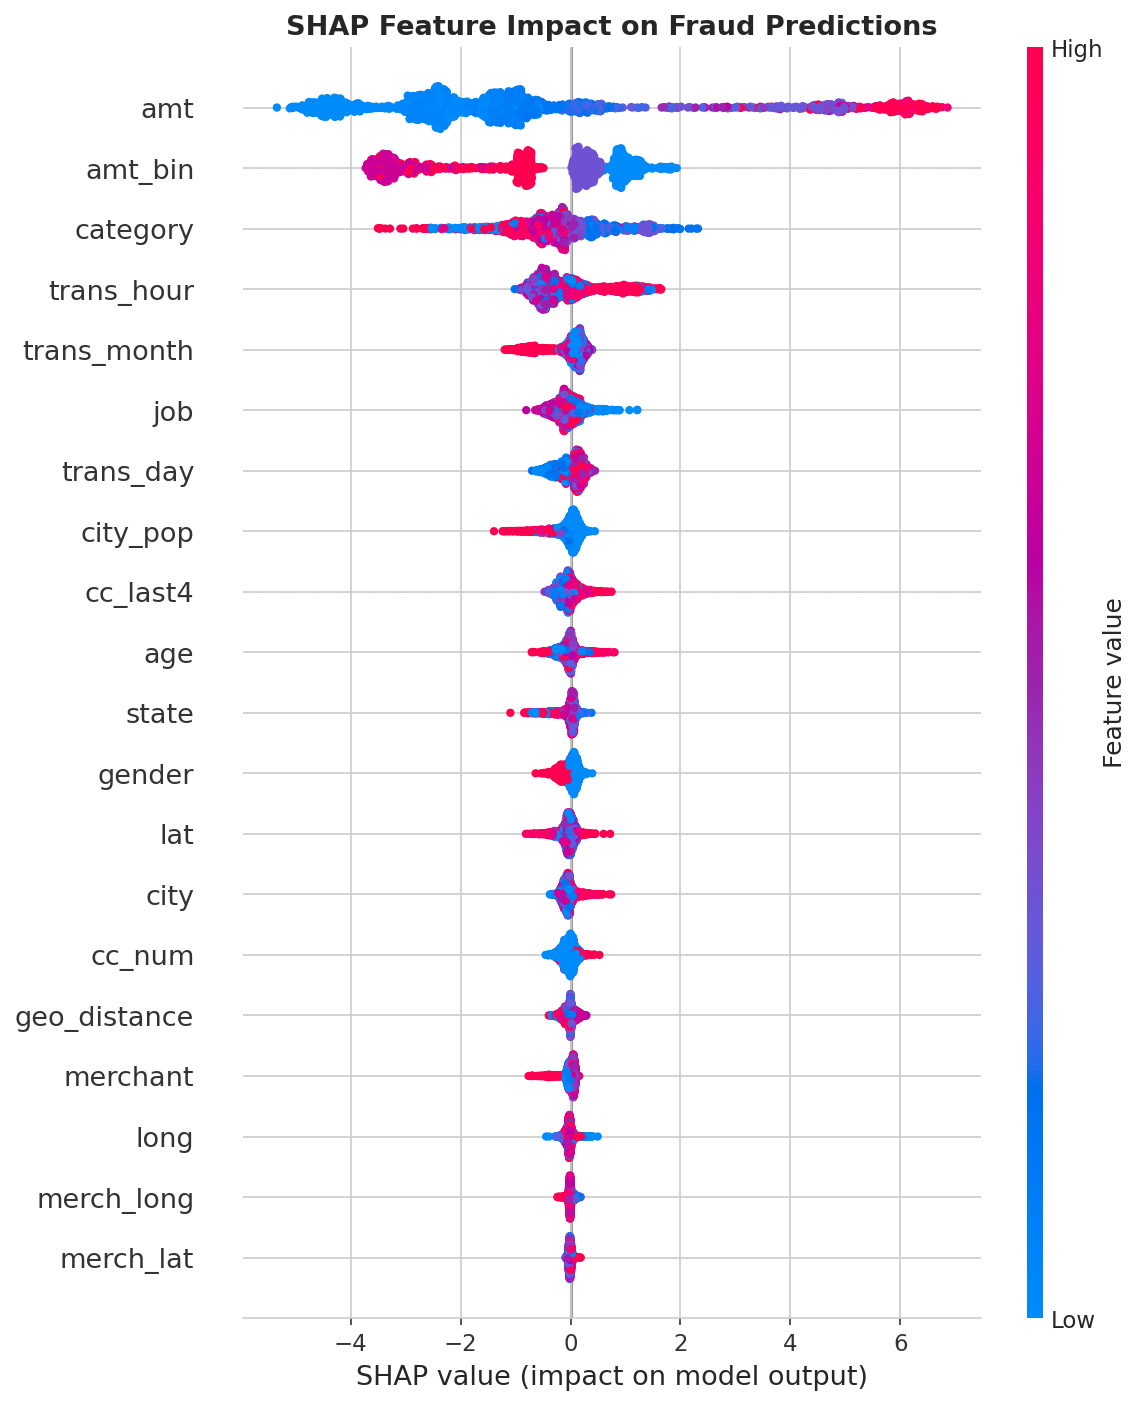

Saved: graph6_shap_beeswarm.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Feature Impact on Fraud Predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graph6_shap_beeswarm.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: graph6_shap_beeswarm.png')

## CELL 16 — GRAPH 7: LIME Local Explanation (Single Transaction)

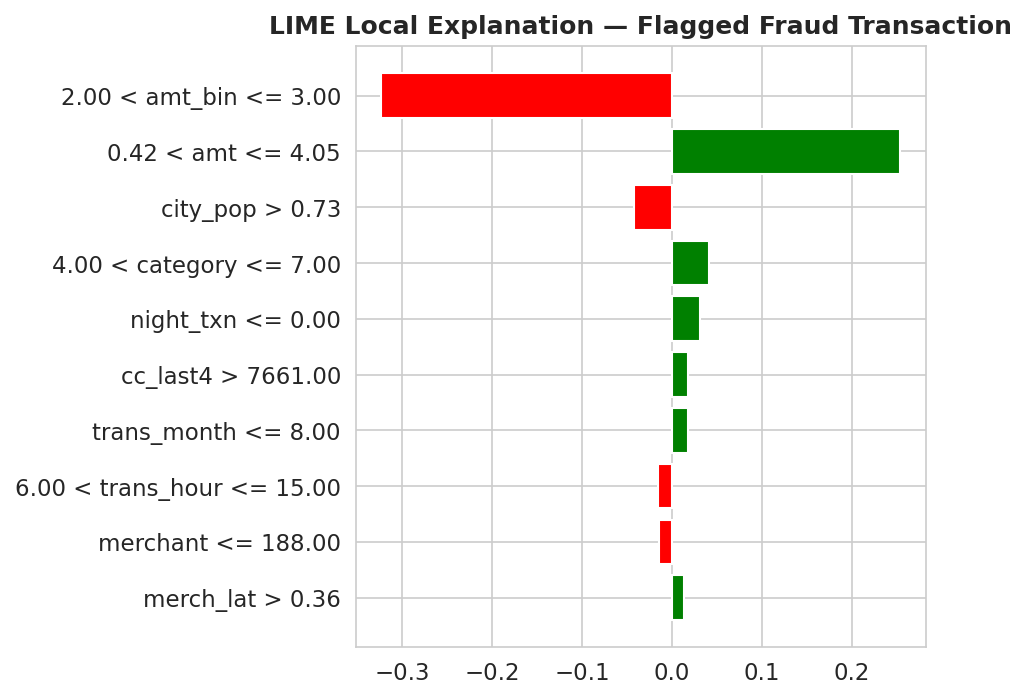

Saved: graph7_lime_explanation.png

Actual label: 1 | Predicted probability of fraud: 0.5897


In [ ]:
# Find a fraud transaction in test set to explain
fraud_idx = np.where(y_test.values == 1)[0][0]

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_sm.values,
    feature_names = X_train_sm.columns.tolist(),
    class_names   = ['Legitimate', 'Fraud'],
    mode          = 'classification',
    random_state  = 42
)

exp = lime_explainer.explain_instance(
    data_row       = X_test.iloc[fraud_idx].values,
    predict_fn     = xgb.predict_proba,
    num_features   = 10
)

fig = exp.as_pyplot_figure()
plt.title('LIME Local Explanation — Flagged Fraud Transaction', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('graph7_lime_explanation.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: graph7_lime_explanation.png')
print(f'\nActual label: {y_test.iloc[fraud_idx]} | Predicted probability of fraud: {xgb.predict_proba(X_test)[fraud_idx,1]:.4f}')

## CELL 17 — GRAPH 8: Class Distribution Before vs After SMOTE

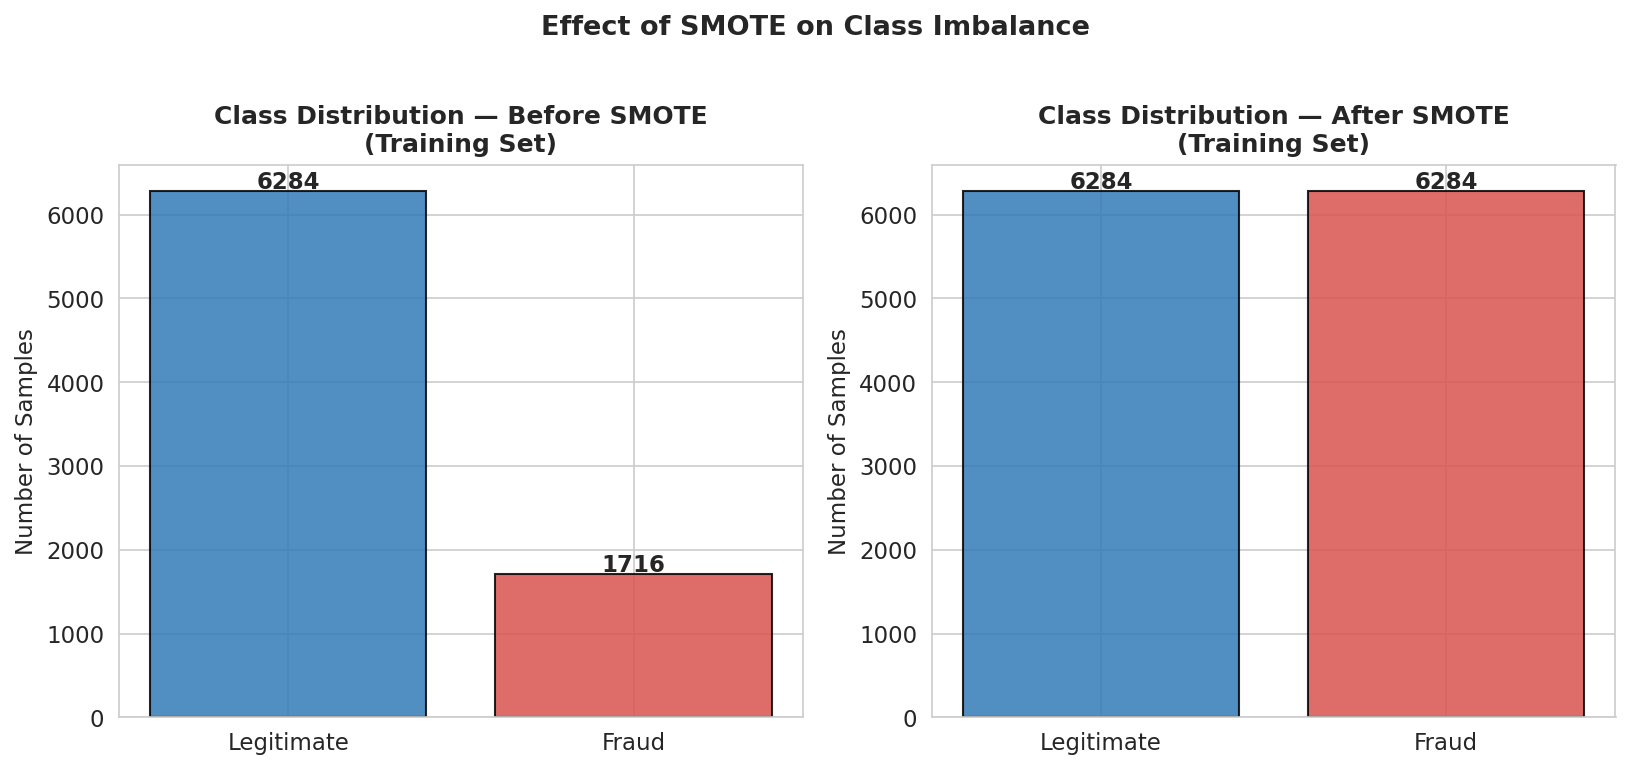

Saved: graph8_smote_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Before SMOTE
before_counts = pd.Series(y_train).value_counts().sort_index()
axes[0].bar(['Legitimate', 'Fraud'], before_counts.values,
            color=['#337ab7', '#d9534f'], edgecolor='black', alpha=0.85)
axes[0].set_title('Class Distribution — Before SMOTE\n(Training Set)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=11)
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# After SMOTE
after_counts = pd.Series(y_train_sm).value_counts().sort_index()
axes[1].bar(['Legitimate', 'Fraud'], after_counts.values,
            color=['#337ab7', '#d9534f'], edgecolor='black', alpha=0.85)
axes[1].set_title('Class Distribution — After SMOTE\n(Training Set)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Samples', fontsize=11)
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.suptitle('Effect of SMOTE on Class Imbalance', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graph8_smote_distribution.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: graph8_smote_distribution.png')

## CELL 18 — Print Final Summary (copy to LaTeX)

In [ ]:
print('=' * 65)
print('          FINAL RESULTS SUMMARY — COPY TO LATEX')
print('=' * 65)
print(results_df.to_string())
print()
print('--- Ensemble Model Detailed Report ---')
print(classification_report(y_test, y_pred_ensemble, target_names=['Legitimate','Fraud']))
print()
print('--- Graphs saved ---')
graphs = [
    'graph1_confusion_matrix.png',
    'graph2_model_comparison.png',
    'graph3_roc_curves.png',
    'graph4_pr_curves.png',
    'graph5_shap_importance.png',
    'graph6_shap_beeswarm.png',
    'graph7_lime_explanation.png',
    'graph8_smote_distribution.png',
]
for g in graphs:
    print(f'  ✓ {g}')
print()
print('Download all graph PNG files and the results table for your LaTeX submission.')

          FINAL RESULTS SUMMARY — COPY TO LATEX
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC     MCC   AUPRC
Model                                                                              
Logistic Regression    0.7855     0.0000  0.0000    0.0000   0.5279  0.0000  0.2321
Decision Tree          0.9345     0.8239  0.8834    0.8526   0.9547  0.8114  0.8743
Random Forest          0.9585     0.9240  0.8788    0.9008   0.9892  0.8751  0.9690
XGBoost                0.9750     0.9438  0.9394    0.9416   0.9934  0.9257  0.9813
LightGBM               0.9755     0.9502  0.9347    0.9424   0.9944  0.9269  0.9817
Ensemble (XGB+LGBM)    0.9760     0.9482  0.9394    0.9438   0.9942  0.9286  0.9826

--- Ensemble Model Detailed Report ---
              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.98      1571
       Fraud       0.95      0.94      0.94       429

    accuracy                           0.98      2000
   macro avg       0.9